# Assignment 2. Option 2

## Dataset Exploration

In [2]:
%load_ext autoreload
%autoreload 2

In [15]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [16]:
from pathlib import Path
from src.dataset import *
from src.models import *
from src.train import *
from torch.utils.data import DataLoader
import soundfile as sf
import pandas as pd
import torch
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10
VAD_MODEL = MODELS_DIR / "vad.pt"
SEGMENTATOR_MODEL = MODELS_DIR / "segmentator.pt"
EMBEDDINGS_MODEL = MODELS_DIR / "xvec.pt"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [17]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_agnostic_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(test_lengths, batch_size=8, shuffle=False),
  collate_fn=make_agnostic_collate_fn(HOP, SAMPLE_RATE),
)

In [18]:
import librosa

pd.Series(
    [librosa.get_samplerate(f) for f in dataset_dev.audio_files + dataset_test.audio_files]
).value_counts()

16000    448
Name: count, dtype: int64

In [19]:
from src.dataset import RTTM_COLUMNS

dev_path = ANNOTATIONS_DIR / DIR_DEV
test_path = ANNOTATIONS_DIR / DIR_TEST

def prep_data(path):
    return pd.concat(
        [pd.read_csv(f, sep=r"\s+", header=None, names=RTTM_COLUMNS) for f in path.iterdir()],
        ignore_index=True,
    )

df_dev = prep_data(dev_path)
df_test = prep_data(test_path)


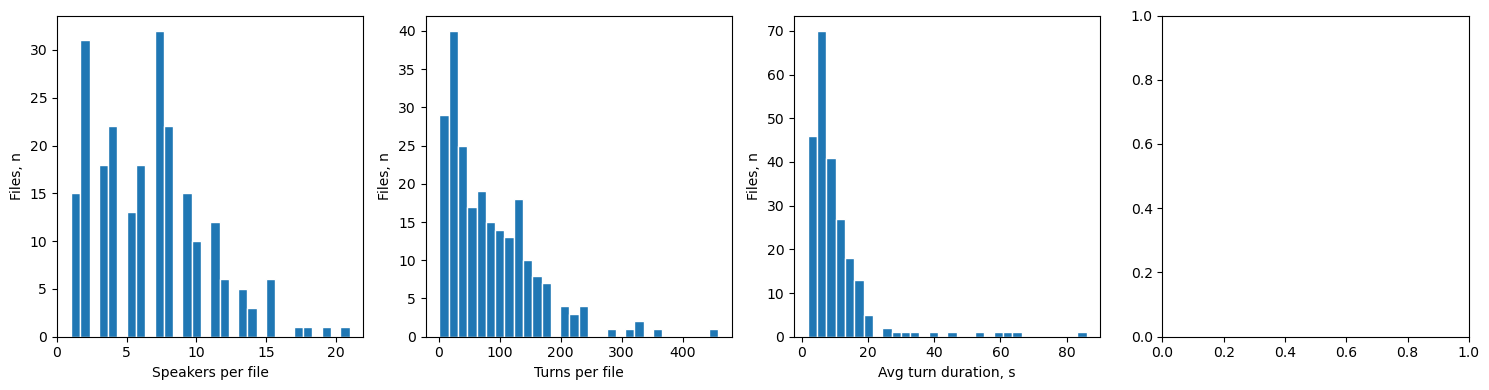

In [20]:
import matplotlib.pyplot as plt

stats = df_test.groupby("file_id").agg(
    n_speakers=("speaker", "nunique"),
    n_turns=("speaker", "count"),
    avg_turn_dur=("duration", "mean"),
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, col, xlabel in zip(
    axes,
    ["n_speakers", "n_turns", "avg_turn_dur"],
    ["Speakers per file", "Turns per file", "Avg turn duration, s"],
):
    ax.hist(stats[col], bins=30, edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Files, n")
    ax.grid(False)

plt.tight_layout()
plt.show()



### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

In [21]:
VAD_RETRAIN=False

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

if VAD_MODEL.exists() and not VAD_RETRAIN:
  vad.load_state_dict(torch.load(VAD_MODEL, weights_only=True))
  print(f"VAD loaded from {VAD_MODEL}")
else:
  epochs = 7
  lr = 1e-3

  print(f"Device: {device}")

  history = train_vad(vad, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(vad.state_dict(), VAD_MODEL)

VAD loaded from models/vad.pt


95434 -> 2983   ratio: 31.99262487428763


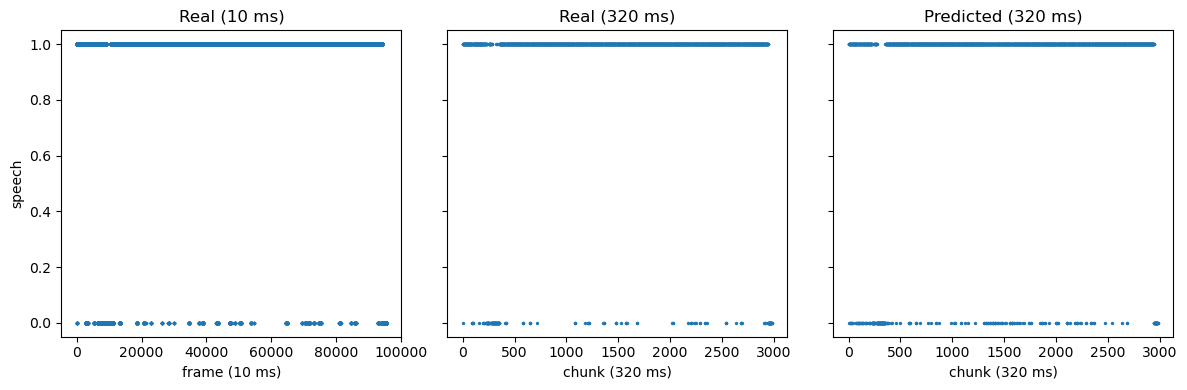

In [22]:
(waveform, labels, mask) = next(iter(dataloader_dev))

m10 = mask[0]
y10 = labels[0][m10].numpy()

with torch.no_grad():
    vad.eval()
    x = tuple(t for t in (waveform, labels, mask))
    pred, labels_c, mask_c = vad(x)

    m0     = mask_c[0]
    truth0 = labels_c[0][m0].cpu().numpy()
    pred0  = (torch.sigmoid(pred[0]) > 0.5)[m0].cpu().numpy()

print(len(y10), "->", len(truth0), "  ratio:", len(y10) / len(truth0))  # expect ~32

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax1.scatter(range(len(y10)), y10, s=2)
ax1.set(title="Real (10 ms)", xlabel="frame (10 ms)", ylabel="speech")

ax2.scatter(range(len(truth0)), truth0, s=2)
ax2.set(title="Real (320 ms)", xlabel="chunk (320 ms)")

ax3.scatter(range(len(pred0)), pred0, s=2)
ax3.set(title="Predicted (320 ms)", xlabel="chunk (320 ms)")

fig.tight_layout()


### A segmentation model utilizing permutation invariant CE loss.

In [24]:
annfile, count = find_max_speakers(dataset_dev)
print(f"Max speakers in dev dataset: {count} - {annfile}")

annfile, count = find_max_speakers(dataset_test)
print(f"Max speakers in test dataset: {count} - {annfile}")

Max speakers in dev dataset: 20 - data/annotations/dev/kdfqk.rttm
Max speakers in test dataset: 21 - data/annotations/test/nitgx.rttm


In [25]:
from src.dataset import *

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=1, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(test_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

In [26]:
SEGMENTATOR_RETRAIN=False

segmentator = Segmentator(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(sample_rate=SAMPLE_RATE, hop_ms=HOP),
)

if SEGMENTATOR_MODEL.exists() and not SEGMENTATOR_RETRAIN:
  segmentator.load_state_dict(torch.load(SEGMENTATOR_MODEL, weights_only=True))
  print(f"Segmentator loaded from {VAD_MODEL}")
else:
  epochs = 3
  lr = 1e-3

  print(f"Device: {device}")

  history = train_segmentator(segmentator, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "segmentator_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(segmentator.state_dict(), SEGMENTATOR_MODEL)

Device: mps
===== EPOCH 1/3 - train =====
  batch   1 | loss 0.6741 | acc 0.780 | P 0.321 | R 0.133 | F1 0.188 | spec 0.878


KeyboardInterrupt: 

In [12]:
list(itertools.permutations(range(3)))

[(0, 1, 2), (0, 2, 1), (1, 0, 2), (1, 2, 0), (2, 0, 1), (2, 1, 0)]

In [ ]:
sample = next(iter(dataloader_test))
segmentator.eval()

waveform, in_labels, in_mask = sample
with torch.no_grad():
    logits, tgt, m = model(tuple(t.to(device) for t in sample))
# (B, W, T, K), (B, W, T, K), (B, W, T) — assume B = 1
logits, tgt, m = logits[0], tgt[0], m[0].bool()           # -> (W, T, K), (W, T, K), (W, T)
probs = torch.sigmoid(logits)

# inspect the window with the most active speakers
w = int((tgt.sum(1) > 0).sum(1).argmax())

# --- PIT-align predicted slots to the target's slot order for this window ---
def best_perm(lg, tg, mk):                                # (T,K),(T,K),(T,)
    mk = mk[:, None].float()
    def cost(p):
        bce = (p.clamp(min=0) - p * tg + torch.log1p((-p.abs()).exp())) * mk
        return float(bce.sum())
    return min(itertools.permutations(range(tg.shape[1])), key=lambda pm: cost(lg[:, pm]))

perm = best_perm(logits[w], tgt[w].float(), m[w])
probs_w = probs[w][:, perm]                               # aligned to target order

# --- time axis: this window's absolute span in the recording ---
hop_ms = model.spectrogram.hop_ms
win = int(model.window_size / hop_ms)
hop = int(model.window_step / hop_ms)
start = w * hop
t = (np.arange(win) + start) * hop_ms / 1000.0           # seconds

# --- original input labels, sliced to the same span ---
il = in_labels[0].cpu().numpy()                          # (K_full, T_full)
sl = il[:, start:start + win]
if sl.shape[1] < win:                                    # last window runs into padding
    sl = np.pad(sl, ((0, 0), (0, win - sl.shape[1])))
keep = sl.any(1)                                         # only speakers active here

def gantt(ax, act, ylabels, title):
    cmap = plt.cm.tab10
    for i in range(act.shape[1]):
        ax.step(t, i + act[:, i] * 0.8, where='post', color=cmap(i % 10), lw=1.4)
        ax.axhline(i, color='0.9', lw=0.5, zorder=0)
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
    ax.set_title(title); ax.set_ylim(-0.2, len(ylabels))

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
gantt(ax[0], sl[keep].T, [f"spk {i}" for i in np.where(keep)[0]],
      f"1. Input labels — window {w} ({keep.sum()} speakers active)")
gantt(ax[1], tgt[w].cpu().numpy().astype(float), [f"slot {i}" for i in range(tgt.shape[1])],
      "2. Target — packed kmax slots")
gantt(ax[2], probs_w.cpu().numpy(), [f"slot {i}" for i in range(tgt.shape[1])],
      "3. Prediction — sigmoid, PIT-aligned (line height = probability)")
ax[2].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## Embeddings

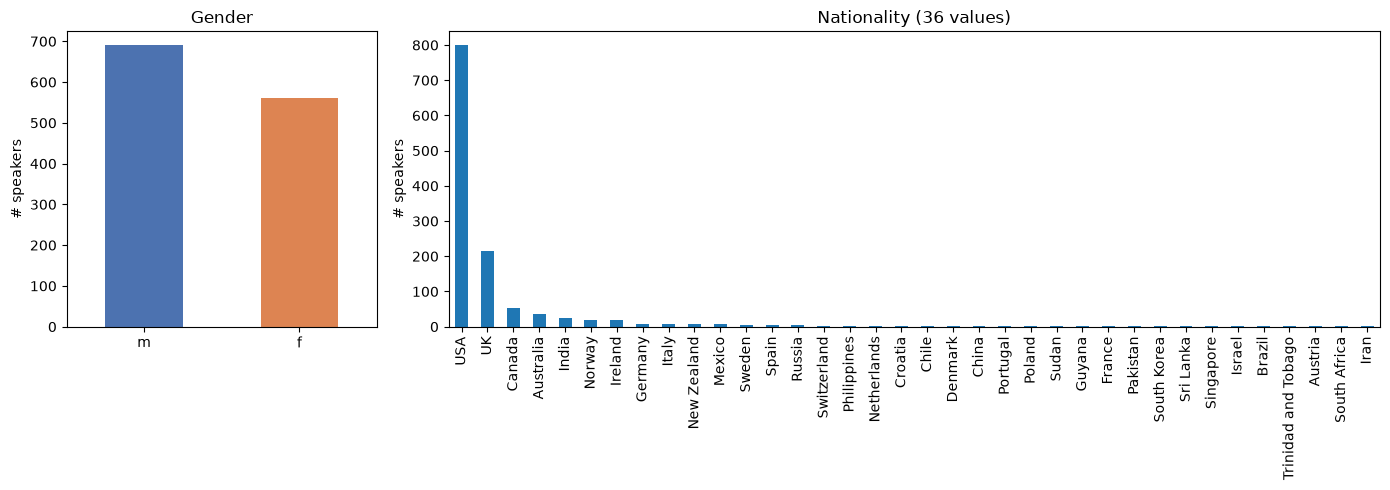

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

meta = pd.read_csv("data/vox_celeb/vox1_meta.csv", sep="\t")
meta.columns = meta.columns.str.strip()         
meta = meta.rename(
    columns={"VoxCeleb1 ID": "speaker", "Gender": "gender", "Nationality": "country", "Set": "split"}
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 3]})

meta["gender"].value_counts().plot.bar(ax=ax1, color=["#4c72b0", "#dd8452"])
ax1.set(title="Gender", xlabel="", ylabel="# speakers")
ax1.tick_params(axis="x", rotation=0)

nat = meta["country"].value_counts()
nat.plot.bar(ax=ax2)
ax2.set(title=f"Nationality ({nat.size} values)", xlabel="", ylabel="# speakers")
ax2.tick_params(axis="x", rotation=90)

fig.tight_layout()
plt.show()

Distribution of males and females is pretty similar, countries are highly USA/UK dominated

In [8]:
from sklearn.model_selection import StratifiedGroupKFold

meta["strat"] = meta["gender"] + "_" + meta["country"]
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=12)
train, val = next(sgkf.split(meta, meta["strat"], groups=meta["speaker"]))
train_df, val_df = meta.iloc[train], meta.iloc[val]

/Users/neprog/mamba/envs/deep-audio/lib/python3.11/site-packages/sklearn/model_selection/_split.py:1036: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


/var/folders/sy/5plrpq6s4lxb_r_q_7kn2kvc0000gn/T/ipykernel_5894/3070245312.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title=None)


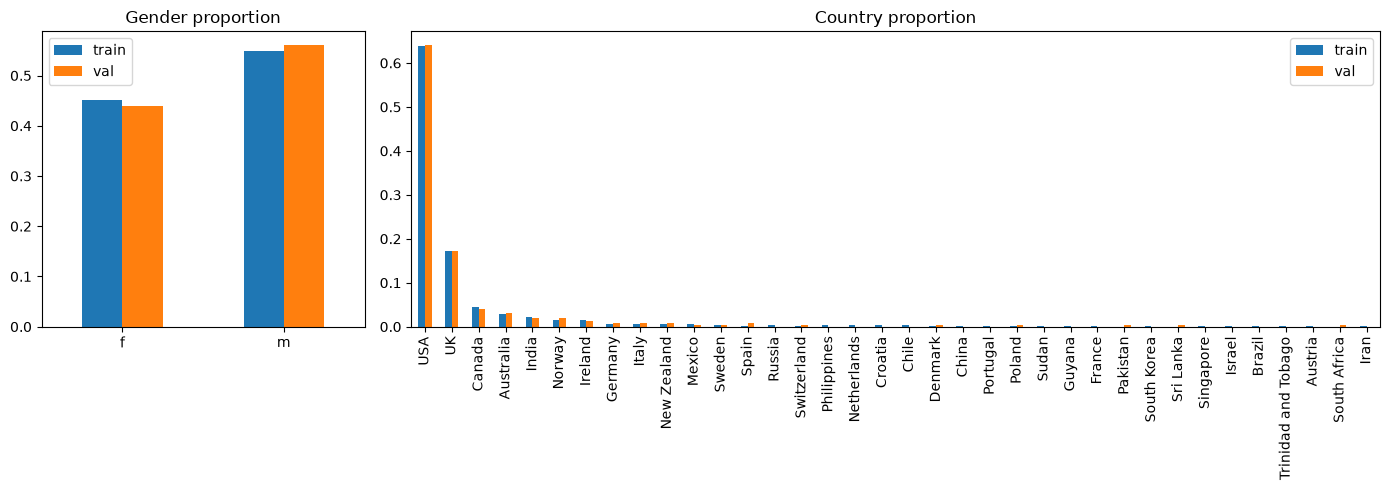

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 3]})

train_gender = pd.crosstab(train_df["gender"], columns="train", normalize=True)
val_gender = pd.crosstab(val_df["gender"], columns="val", normalize=True)
train_gender.join(val_gender).plot.bar(ax=ax1)

ax1.set(title="Gender proportion", xlabel="")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(title=None)
ax2.legend(title=None)

order = meta["country"].value_counts().index
g = train_df["country"].value_counts(normalize=True).reindex(order)
v = val_df["country"].value_counts(normalize=True).reindex(order)
pd.DataFrame({"train": g, "val": v}).plot.bar(ax=ax2)
ax2.set(title="Country proportion", xlabel="")
ax2.tick_params(axis="x", rotation=90)

fig.tight_layout()
plt.show()

In [10]:
from pathlib import Path

def manifest(df, root=Path("data/vox_celeb/vox1_dev_wav")):
    items = []
    for speaker in df["speaker"]:
        for wav in (root / speaker).rglob("*.wav"):
            items.append((wav, speaker))
    return items

train_items = manifest(train_df)
val_items   = manifest(val_df)

print(len(train_items), len(val_items))
print(train_items[0])

118072 30570
(PosixPath('data/vox_celeb/vox1_dev_wav/id10001/J9lHsKG98U8/00026.wav'), 'id10001')


In [11]:
from torch.utils.data import Dataset
  
class VoxCelebDataset(Dataset):
    def __init__(self, items, spk2idx, sr=16000, crop_s=3.0):
        self.sr, self.n = sr, int(crop_s * sr)
        self.items = [(p, s) for p, s in items if sf.info(p).frames >= self.n]
        self.spk2idx = spk2idx

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, spk = self.items[i]
        y, _ = librosa.load(path, sr=self.sr)
        s = random.randint(0, len(y) - self.n)
        y = y[s:s + self.n]
        return torch.from_numpy(y).float(), self.spk2idx.get(spk, -1)
      
      
spk2idx = {s: i for i, s in enumerate(sorted(train_df["speaker"]))}

train_ds = VoxCelebDataset(train_items, spk2idx)
val_ds = VoxCelebDataset(val_items, spk2idx)

In [12]:
from torch.utils.data import DataLoader                                     

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds,   batch_size=64, shuffle=False)

wav, y = next(iter(train_dl))
print(wav.shape)

torch.Size([64, 48000])


In [17]:
from src.embeddings import XVector
from src.train import train_xvector

EMBEDDINGS_RETRAIN = False

xvec = XVector(
    device=device,
    spectrogram_layer=MelSpectrogramExtractor(sample_rate=SAMPLE_RATE, hop_ms=HOP, mel_bands=40),
    n_speakers=len(spk2idx)
)

if EMBEDDINGS_MODEL.exists() and not EMBEDDINGS_RETRAIN:
      xvec.load_state_dict(torch.load(EMBEDDINGS_MODEL, weights_only=True))
      print(f"Embeddings model loaded from {EMBEDDINGS_MODEL}")
else:
    epochs = 10
    lr = 1e-3
    print(f"Device: {device}")

    history = train_xvector(xvec, device, lr, epochs, train_dl)

    MODELS_DIR.mkdir(exist_ok=True)
    torch.save(xvec.state_dict(), EMBEDDINGS_MODEL)

Embeddings model loaded from models/xvec.pt


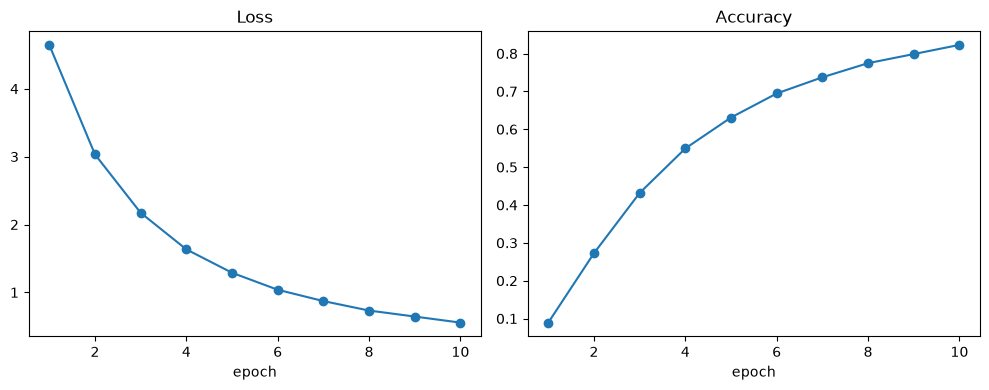

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
xs = range(1, len(history["train_loss"]) + 1)
ax1.plot(xs, history["train_loss"], marker="o"); ax1.set(title="Loss", xlabel="epoch")
ax2.plot(xs, history["train_acc"], marker="o");  ax2.set(title="Accuracy", xlabel="epoch")
fig.tight_layout()

In [21]:
import numpy as np,  torch
from sklearn.metrics import roc_curve

test_items = manifest(meta[meta["split"] == "test"], root=Path("data/vox_celeb/vox1_test_wav"))
test_ds = VoxCelebDataset(test_items, spk2idx)

@torch.no_grad()
def embed_dataset(model, ds, items):
    model.eval()
    dl = DataLoader(ds, batch_size=64, shuffle=False)
    embeddings = []
    for wav, _ in dl:                                   
        vec = model(wav.to(device), return_embedding=True)
        embeddings.append(vec.cpu().numpy())
    embeddings = np.concatenate(embeddings)
    speakers = np.array([s for _, s in items])          
    return embeddings, speakers

embeddings, speakers = embed_dataset(xvec, val_ds, val_items)

xvec.to(device)
embeddings, speakers = embed_dataset(xvec, test_ds, test_items)

sim = embeddings @ embeddings.T
pairs = np.triu_indices(len(embeddings), k=1)
sims, same = sim[pairs], (speakers[:, None] == speakers[None, :])[pairs]

far, tar, _ = roc_curve(same, sims)
frr = 1 - tar
eer = far[np.nanargmin(np.abs(far - frr))]
print(f"EER = {eer * 100:.2f}%")

EER = 28.65%
